In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
import os
from sklearn.metrics import accuracy_score
import torchvision
import zipfile
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Libraries

## Utilities

In [2]:
def stable_softmax(logits):
    # Numerically stable softmax
    predictions = torch.exp(logits - torch.max(logits, dim=-1, keepdims=True).values)
    predictions = predictions / torch.sum(predictions, dim=-1, keepdims=True)
    return predictions

def predict_labels(model, dl, device="cpu"):
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            logits = model(imgs)
            predictions = logits.argmax(dim=1)
            y_pred.append(predictions.cpu())
            y_true.append(lbls.cpu())
    
    return torch.cat(y_true), torch.cat(y_pred)

def predict_proba(model, ds, device="cpu", use_stable_softmax=False, return_labels = False):
    model.eval()
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    probs = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits = model(imgs)
            if use_stable_softmax:
                p = stable_softmax(logits)
                probs.extend(p)
            else:
                probs.extend(F.softmax(logits, dim=1))

            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(probs), torch.stack(labels)
    else:
        return torch.stack(probs)

def compute_logits(model, ds, device="cpu", return_labels = False):
    model.eval()
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    logits = []
    labels = []
    with torch.no_grad():
        for imgs, lbls in dl:
            imgs, lbls = imgs.to(device), lbls.to(device)

            logits.extend(model(imgs))
            if return_labels:
                labels.extend(lbls)
    
    if return_labels:
        return torch.stack(logits), torch.stack(labels)
    else:
        return torch.stack(logits)

def predict_phi_scores(model, ds, device="cpu", return_labels=False):
    probs, labels = predict_proba(model, ds, device=device, use_stable_softmax=True, return_labels=True)
    probs, labels = probs.cpu().numpy(), labels.cpu().numpy()
    
    # Compute probability of the true class and the probability of all other classes
    # np.arange(predictions.shape[0]) is needed to correctly indexing of numpy array
    p_true = probs[np.arange(probs.shape[0]), labels]
    probs[np.arange(probs.shape[0]), labels] = 0
    p_wrong = np.sum(probs, axis=-1)

    # Compute phi
    eps = 1e-45
    phis = np.log(p_true + eps) - np.log(p_wrong + eps)
    
    if return_labels:
        return phis, labels
    else:
        return phis

def predict_losses(model, ds, device="cpu", return_labels=False):
    logits, labels = compute_logits(model, ds, device=device, return_labels=True)  
    losses = F.cross_entropy(logits, labels, reduction="none")

    losses, labels = losses.cpu().numpy(), labels.cpu().numpy()

    if return_labels:
        return losses, labels
    else:
        return losses



def get_labels(ds):
    dl = DataLoader(ds, batch_size=1024)
    labels = []
    for _, lbls in dl:
        labels.extend(lbls)
    
    return torch.tensor(labels)


def compute_accuracy(model, dl, device="cpu"):
    y_true, y_pred = predict_labels(model, dl, device=device)
    return accuracy_score(y_true=y_true, y_pred=y_pred)

def compute_error_rate(model, dl, device="cpu"):
    return 1 - compute_accuracy(model, dl, device=device)


def save_model(model, name, verbose=True, device="cuda"):
    if device=="cuda":
        torch.save(model.state_dict(), f"{name}.pth")
        if verbose:
            print(f"Model params saved in '{name}.pth'")
    
    model = model.to("cpu")
    torch.save(model.state_dict(), f"{name}_cpu.pth")
    if verbose:
        print(f"Model params saved in '{name}_cpu.pth'")
    
    model.to(device)

def load_model(model, name, verbose=True, device="cuda"):
    if device=="cpu":
        path = f"{name}_cpu.pth"
    else:
        path = f"{name}.pth"
    model.load_state_dict(torch.load(path))
    if verbose:
        print(f"Model loaded from '{path}'")

def save_array(arr, name, verbose=True):
    np.save(f"{name}.npy", arr)
    if verbose:
        print(f"Array saved in '{name}.npy'")

def load_array(name, verbose=True):
    arr = np.load(f"{name}.npy")
    if verbose:
        print(f"Array loaded from '{name}.npy'")
    return arr



def roc_chart(true_memberships, scores, axis: plt.Axes, color="darkorange", title="", log_scale=False):

    fpr, tpr, roc = roc_curve(true_memberships, scores)

    axis.plot(fpr, tpr, color=color, lw=1, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
    axis.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    if log_scale:
        axis.set_xlim([1e-5, 1.0])
        axis.set_ylim([1e-5, 1.0])
        axis.set_xscale("log")
        axis.set_yscale("log")
    else:
        axis.set_xlim([0, 1.0])
        axis.set_ylim([0, 1.0])
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    if title!= "":
        axis.set_title(title)
    else:
        axis.set_title('ROC')
    axis.legend(loc="lower right")



def get_activation(name, dict):
    def hook(model, input, output):
        dict[name] = output.detach()
    return hook

def get_activations(model, img):
    handles = []
    activations = {}

    for name, layer in model.named_modules():
        if name != "":
            handles.append(layer.register_forward_hook(get_activation(name, activations)))
    
    model(img)

    for handle in handles:
        handle.remove() 

    return activations


def get_distance_between_models(model1, model2):
    with torch.no_grad():
        model1_flattened = nn.utils.parameters_to_vector(model1.parameters())
        model2_flattened = nn.utils.parameters_to_vector(model2.parameters())
        distance = torch.square(torch.norm(model1_flattened - model2_flattened))
    return distance



## FedAvg


In [3]:
import copy
from torch.utils.data import ConcatDataset, DataLoader
from typing import Any

###################
# CLASSES
###################

class Client:
    def __init__(self, id, ds, model, dl = None, data_idxs = None):
        self.id = id
        self.ds = ds
        self.dl = dl
        self.data_idxs = data_idxs
        self.model = model

class RoundLog:
    def __init__(self, round_, global_model, client_updates: dict[int, Any]):
        self.round = round_
        self.global_model = global_model
        self.client_updates = client_updates
    
    def get_partecipating_client_ids(self):
        return self.client_updates.keys()


###################
# FEDAVG
###################

def fedavg_from_state_dict(global_model, client_dicts, client_weights):
    global_model = copy.deepcopy(global_model)

    avg = {}
    total_weights = sum(client_weights)
    for key in client_dicts[0].keys():
        avg[key] = sum([client_weights[i]*cd[key] for i, cd in enumerate(client_dicts)]) / total_weights

    global_model.load_state_dict(avg)
    return global_model

def fedavg_with_weights(clients, client_weights):
    client_dicts = [c.model.state_dict() for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg_from_models(client_models, client_weights):
    client_dicts = [model.state_dict() for model in client_models]
    return fedavg_from_state_dict(client_models[0], client_dicts, client_weights)

def fedavg_data_based_weights(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [len(c.ds) for c in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def fedavg(clients):
    client_dicts = [c.model.state_dict() for c in clients]
    client_weights = [1 for _ in clients]
    return fedavg_from_state_dict(clients[0].model, client_dicts, client_weights)

def train_client(train_fn, global_model, client, epochs, device="cpu", inplace=False):
    client_model = copy.deepcopy(global_model)

    train_fn(client_model, client.dl, epochs, device=device)

    if inplace:
        client.model = client_model

    return client_model

def train_fedavg(init_global_model, clients, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):

    global_model = init_global_model
    if verbose:
        train_ds = ConcatDataset([c.ds for c in clients])
        train_dl = DataLoader(train_ds, batch_size=256)

    if return_log:
        logs = []
        global_model = global_model.cpu()
        logs.append(RoundLog(0, copy.deepcopy(global_model), {}))
        global_model = global_model.to(device)
    
    for r in range(1, rounds+1):
        client_updates = {}
        for client in clients:
            client_model = train_client(train_fn, global_model, client, epochs, device=device, inplace=False)
            if return_log:
                client_model = client_model.cpu()
                client_updates[client.id] = copy.deepcopy(client_model)
                client_model = client_model.to(device)
            client.model = client_model

        global_model = fedavg(clients)
        if return_log:
            global_model = global_model.cpu()
            logs.append(RoundLog(1, copy.deepcopy(global_model), client_updates))
            global_model = global_model.to(device)

        if verbose:
            #global_model = global_model.to(device)
            train_acc = compute_accuracy(global_model, train_dl, device=device)

            eval_acc = -1
            if eval_dl != None:
                eval_acc = compute_accuracy(global_model, eval_dl, device=device)
            
            print(f"Ended training for round {r}/{rounds}, train acc = {train_acc:.4f}, eval acc = {eval_acc:.4f}")

    if return_log:
        return global_model, logs
    else:
        return global_model


def fed_retrain(init_global_model, clients, client_ids_to_unlearn, rounds, epochs, train_fn, device="cpu", return_log=False, verbose=False, eval_dl = None):
    remaining_clients = [c for c in clients if c.id not in client_ids_to_unlearn]
    return train_fedavg(init_global_model, remaining_clients, rounds, epochs, train_fn, device=device, return_log=return_log, verbose=verbose, eval_dl = eval_dl)
###################


## Splitted FedAvg

In [35]:
def split_client_update(client, global_model, split_layers):
    global_state_dict = global_model.state_dict()
    client_state_dict = client.model.state_dict()

    for name, param in global_state_dict.items():
        if not name.startswith(split_layers):
            client_state_dict[name].copy_(param)

    client.model.load_state_dict(client_state_dict)

def train_splitted_fedavg(init_global_model, clients, rounds, epochs, train_fn, split_layers, 
                          train_clean_dl, train_backdoor_dl, eval_clean_dl, eval_backdoor_dl, device="cpu"):


    global_model = init_global_model
    for client in clients:
        client.model.load_state_dict(global_model.state_dict())
    
    for r in range(1, rounds+1):
        for client in clients:
            client_model = train_client(train_fn, client.model, client, epochs, device=device, inplace=False)
            client.model = client_model

        global_model = fedavg(clients)

        for client in clients:
            split_client_update(client, global_model, split_layers)


        clean_train_acc = compute_accuracy(global_model, train_clean_dl, device=device)
        clean_eval_acc = compute_accuracy(global_model, eval_clean_dl, device=device)
        backdoor_train_acc = compute_accuracy(global_model, train_backdoor_dl, device=device)
        backdoor_eval_acc = compute_accuracy(global_model, eval_backdoor_dl, device=device)

        print(f"Ended training for round {r}/{rounds} - global model: clean train acc: {clean_train_acc:.4f}, clean eval acc = {clean_eval_acc:.4f} backdoor train acc: {backdoor_train_acc:.3f}, backdoor eval acc: {backdoor_eval_acc:.3f}")

        backdoor_accs = []
        for client in clients:
            backdoor_accs.append(compute_accuracy(client.model, eval_backdoor_dl, device=device))
        print(f"Backdoor accuracies for each client: ", [f"{x:.2f}" for x in backdoor_accs])
        

    return global_model

def unlearn_model(clients, cleints_ids_to_unlearn):
    retained_clients = [c for c in clients if c.id not in cleints_ids_to_unlearn]
    return fedavg(retained_clients)

# Train Functions

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def create_model(classes, device="cpu"):

    #########################
    # RESNET18

    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, classes)
    model = model.to(device)

    #########################

    return model

def train_model(model, dl, lr, momentum, epochs, device="cpu", inplace=False):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()
    
    model.to(device)
    model.train()
    
    for e in range(epochs):
        for data, target in dl:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            pred = model(data)
            
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

    return model

# DS Loading

In [19]:
from PIL import Image

class AddBackdoor:
    def __init__(self, size=4, value=255):
        self.size = size
        self.value = value

    def __call__(self, img):
        
        arr = np.array(img)
        h, w, _ = arr.shape
        arr[h-self.size:h, w-self.size:w] = 255

        img = Image.fromarray(arr)

        return img

In [32]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

N_CLIENTS, CLIENT_SIZE = 10, 1000
ROUNDS, EPOCHS = 10, 10

BATCH_SIZE = 64
CLIENT_IDS_WITH_BACKDOOR= [0, 1, 2]

SEED = 1
LR = 0.005
MOMENTUM = 0.9

torch.manual_seed(SEED)
np.random.seed(SEED)

IN_CH = 3
IN_W, IN_H = 32, 32
CLASSES = 10

NORMALIZATION_MEANS, NORMALIZATION_STDS = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)


# Load DS
clean_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(NORMALIZATION_MEANS, NORMALIZATION_STDS)])
backdoor_transform = transforms.Compose([AddBackdoor(4, 255), transforms.ToTensor(), transforms.Normalize(NORMALIZATION_MEANS, NORMALIZATION_STDS)])

ds_train_clean = CIFAR10(root="./data", train=True, download=True, transform=clean_transform)
ds_train_backdoor = CIFAR10(root="./data", train=True, download=True, transform=backdoor_transform)
ds_train_backdoor.targets = [0] * len(ds_train_backdoor.targets)

ds_test_clean = CIFAR10(root="./data", train=False, download=True, transform=clean_transform)
ds_test_backdoor = CIFAR10(root="./data", train=False, download=True, transform=backdoor_transform)
ds_test_backdoor.targets = [0] * len(ds_test_backdoor.targets)

test_clean_dl = DataLoader(ds_test_clean, batch_size=256, shuffle=False)
test_backdoor_dl = DataLoader(ds_test_backdoor, batch_size=256, shuffle=False)

# Create clients
clients: list[Client] = []
idxs = np.array_split(np.arange(N_CLIENTS*CLIENT_SIZE), N_CLIENTS)

for i in range(N_CLIENTS):
    if i not in CLIENT_IDS_WITH_BACKDOOR:
        ds = Subset(ds_train_clean, indices=idxs[i])
    else:
        ds = Subset(ds_train_backdoor, indices=idxs[i])

    dl = DataLoader(ds, batch_size=BATCH_SIZE)
    clients.append(Client(i, ds, create_model(CLASSES, device=device), dl=dl, data_idxs=idxs[i]))

#not_used_ds_train = Subset(ds_train_clean, np.arange(N_CLIENTS*CLIENT_SIZE, len(ds_train_clean)))

clean_clients = [c for c in clients if c.id not in CLIENT_IDS_WITH_BACKDOOR]
backdoor_clients = [c for c in clients if c.id in CLIENT_IDS_WITH_BACKDOOR]

clean_train_ds = ConcatDataset([c.ds for c in clean_clients])
backdoor_train_ds = ConcatDataset([c.ds for c in backdoor_clients])




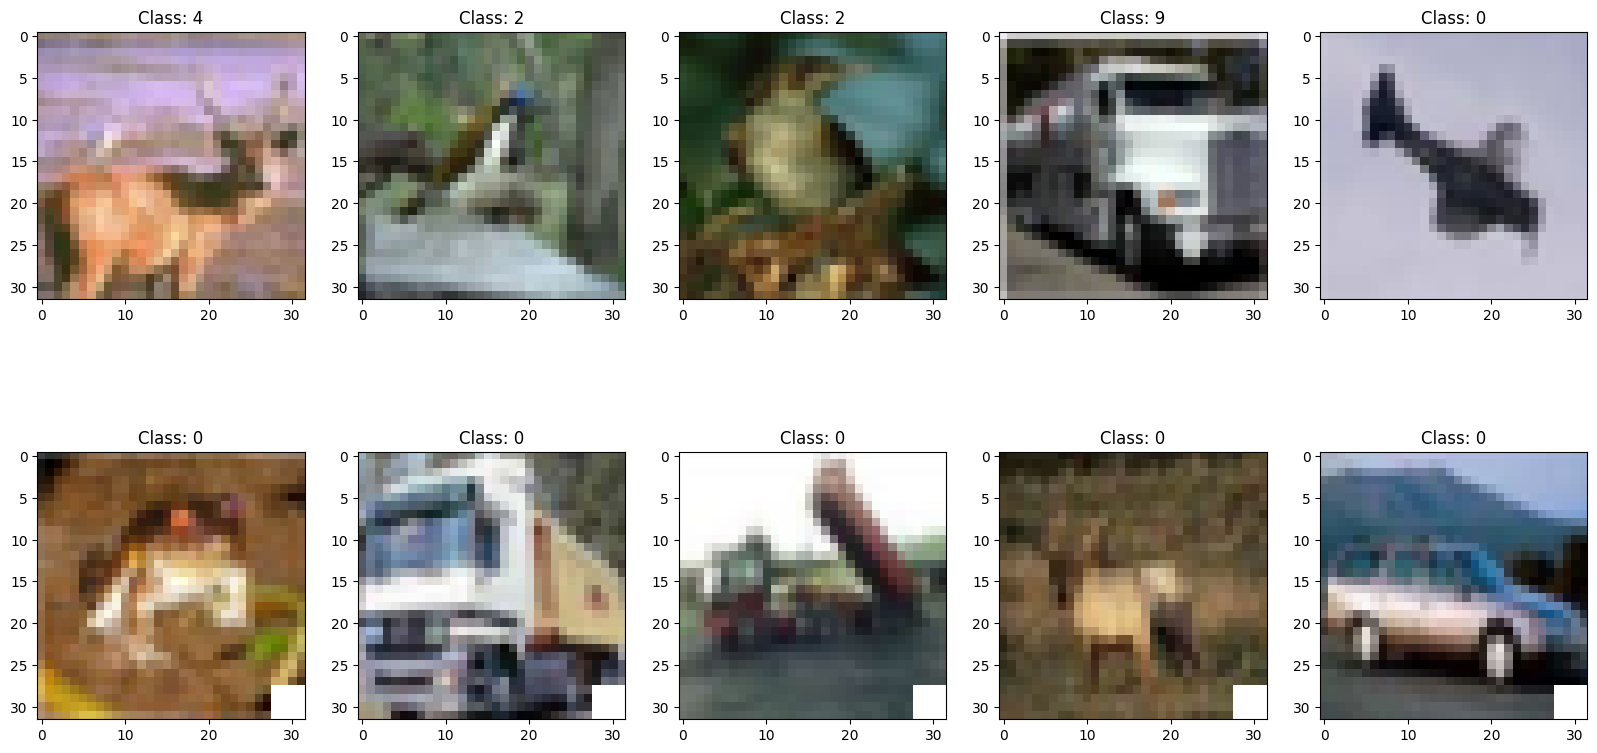

In [24]:
def show_img(img, axis):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)

    img = img * std + mean
    img = img.clamp(0,1)

    axis.imshow(img.permute(1,2,0))


fig, axes = plt.subplots(2, 5, figsize=(20, 10))

clean_imgs, clean_lbls = next(iter(clients[-1].dl))
backdoor_imgs, backdoor_lbls = next(iter(clients[CLIENT_IDS_WITH_BACKDOOR[0]].dl))

for i in range(5):
    axes[0, i].set_title(f"Class: {clean_lbls[i]}")
    show_img(clean_imgs[i], axes[0, i])
    axes[1, i].set_title(f"Class: {backdoor_lbls[i]}")
    show_img(backdoor_imgs[i], axes[1, i])

# Training

In [28]:
# Training function
train_fn = lambda model, dl, epochs, device, inplace=False: train_model(model, dl, LR, MOMENTUM, epochs, device, inplace=inplace)

# Global model
init_global_model = create_model(CLASSES, device=device)
print(init_global_model.state_dict().keys())

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.bn1.num_batches_tracked', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', '

In [36]:
train_clean_dl = DataLoader(clean_train_ds, batch_size=256, shuffle=False)
train_backdoor_dl = DataLoader(backdoor_train_ds, batch_size=256, shuffle=False)

global_model = train_splitted_fedavg(init_global_model, clients, ROUNDS, EPOCHS, train_fn, ("fc"),
                                     train_clean_dl, train_backdoor_dl, test_clean_dl, test_backdoor_dl,
                                     device=device)

train_clean_acc = compute_accuracy(global_model, train_clean_dl, device=device)
train_backdoor_acc = compute_accuracy(global_model, train_backdoor_dl, device=device)

test_clean_acc = compute_accuracy(global_model, test_clean_dl, device=device)
test_backdoor_acc = compute_accuracy(global_model, test_backdoor_dl, device=device)

print(f"Model achived: clean train acc: {train_clean_acc:.3f}, clean test acc: {test_clean_acc:.3f}, backdoor train acc: {train_backdoor_acc:.3f}, backdoor test acc: {test_backdoor_acc:.3f}")

Ended training for round 1/10 - global model: clean train acc: 0.1009, clean eval acc = 0.1004 backdoor train acc: 1.000, backdoor eval acc: 1.000
Backdoor accuracies for each client:  ['1.00', '1.00', '1.00', '0.05', '0.13', '0.10', '0.13', '0.15', '0.08', '0.09']
Ended training for round 2/10 - global model: clean train acc: 0.1159, clean eval acc = 0.1085 backdoor train acc: 0.987, backdoor eval acc: 0.988
Backdoor accuracies for each client:  ['1.00', '1.00', '1.00', '0.09', '0.09', '0.08', '0.09', '0.11', '0.10', '0.09']
Ended training for round 3/10 - global model: clean train acc: 0.1487, clean eval acc = 0.1265 backdoor train acc: 0.957, backdoor eval acc: 0.958
Backdoor accuracies for each client:  ['1.00', '1.00', '1.00', '0.11', '0.09', '0.07', '0.08', '0.11', '0.10', '0.09']
Ended training for round 4/10 - global model: clean train acc: 0.2024, clean eval acc = 0.1475 backdoor train acc: 0.913, backdoor eval acc: 0.916
Backdoor accuracies for each client:  ['1.00', '1.00', 

# Unlearning

In [37]:
unl_global_model = unlearn_model(clients, CLIENT_IDS_WITH_BACKDOOR)

train_clean_dl = DataLoader(clean_train_ds, batch_size=256, shuffle=False)
train_backdoor_dl = DataLoader(backdoor_train_ds, batch_size=256, shuffle=False)

train_clean_acc = compute_accuracy(unl_global_model, train_clean_dl, device=device)
train_backdoor_acc = compute_accuracy(unl_global_model, train_backdoor_dl, device=device)

test_clean_acc = compute_accuracy(unl_global_model, test_clean_dl, device=device)
test_backdoor_acc = compute_accuracy(unl_global_model, test_backdoor_dl, device=device)

print(f"Unlearned model: clean train acc: {train_clean_acc:.3f}, clean test acc: {test_clean_acc:.3f}, backdoor train acc: {train_backdoor_acc:.3f}, backdoor test acc: {test_backdoor_acc:.3f}")

Unlearned model: clean train acc: 0.985, clean test acc: 0.463, backdoor train acc: 0.092, backdoor test acc: 0.105
